# 02 - Huấn luyện và So sánh

**Giai đoạn trong pipeline:** ... -> Mô hình cơ sở -> **Huấn luyện -> Giám sát -> Validation /
Lựa chọn mô hình -> Thí nghiệm** -> Đánh giá trên tập test cuối cùng -> ...

Notebook này nạp các **artifact đã lưu** từ các lần chạy chính thức (`runs/<model>/run_XXX/`)
được tạo ra bởi `scripts/train.py` - nó không huấn luyện lại bất cứ điều gì. Chúng ta so sánh:

1. `mlp/run_001` - MLP baseline
2. `cnn/run_001` - CNN baseline
3. `cnn/run_002` - CNN experiment (dropout 0.3 -> 0.5)


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd

from src.visualization import plot_accuracy_curve, plot_loss_curve

RUNS = {
    "MLP cơ sở": PROJECT_ROOT / "runs" / "mlp" / "run_001",
    "CNN cơ sở": PROJECT_ROOT / "runs" / "cnn" / "run_001",
    "CNN thí nghiệm (dropout 0.5)": PROJECT_ROOT / "runs" / "cnn" / "run_002",
}


## Bảng tổng hợp thí nghiệm

Được nạp trực tiếp từ `experiments/experiment_summary.csv`, do `scripts/compare_models.py`
tạo ra từ `config.yaml` + `metrics/final_metrics.json` thật của từng lần chạy - không có
số liệu nào ở đây được gõ tay.


In [2]:
summary_df = pd.read_csv(PROJECT_ROOT / "experiments" / "experiment_summary.csv")
summary_df

,run_id,model,description,learning_rate,batch_size,epochs,dropout,augmentation,best_epoch,best_val_loss,best_val_accuracy,test_accuracy_if_final,conclusion
0,cnn/run_001,cnn,cnn_baseline,0.001,64,15,0.3,False,7,0.226952,0.919500,0.9161,CNN baseline vượt trội rõ rệt so với MLP basel...
1,cnn/run_002,cnn,cnn_experiment,0.001,64,15,0.5,False,12,0.228184,0.926167,0.9204,Tăng dropout từ 0.3 lên 0.5 cải thiện nhẹ vali...
2,mlp/run_001,mlp,mlp_baseline,0.001,64,15,0.2,False,11,0.301826,0.890167,0.8847,Thiết lập baseline tham chiếu. Đạt ~89% valida...


## Lịch sử huấn luyện (đồ thị loss và accuracy)

File `metrics/history.csv` của mỗi lần chạy chứa một dòng cho mỗi epoch (train/val loss,
train/val accuracy, learning rate). Chúng ta vẽ đồ thị của từng lần chạy trực tiếp từ file
CSV gốc này - không phải từ bộ nhớ hay huấn luyện lại.


/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11443/3835787687.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11443/3835787687.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11443/3835787687.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11443/3835787687.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11443/3835787687.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
/var/folders/1g/g3jtxqks749bhmtvz3n303wc0000gn/T/ipykernel_11443/3835787687.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be sh

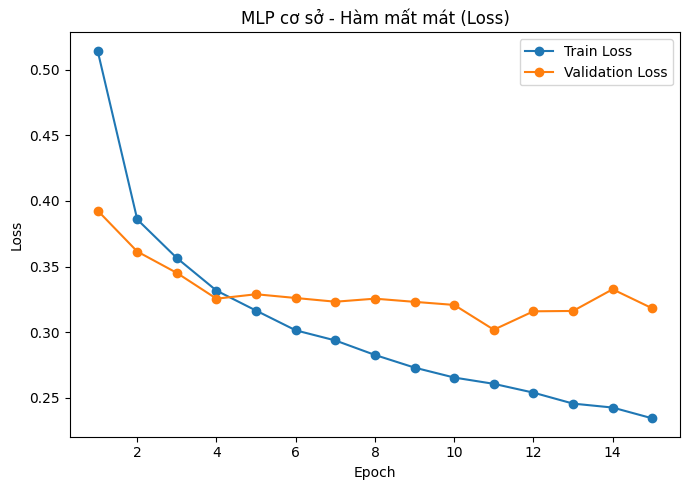

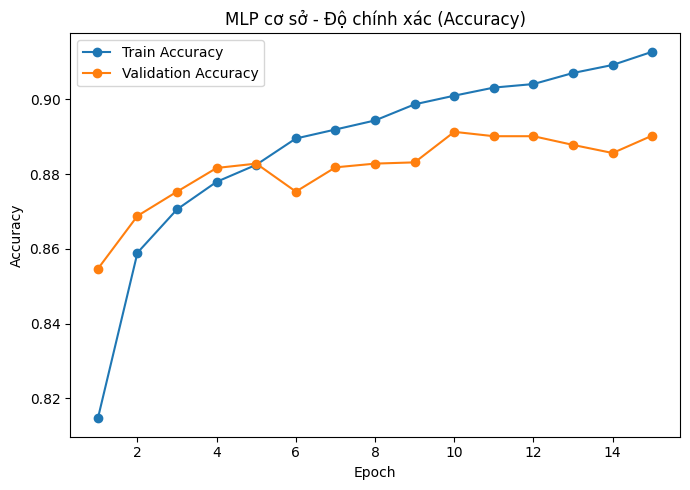

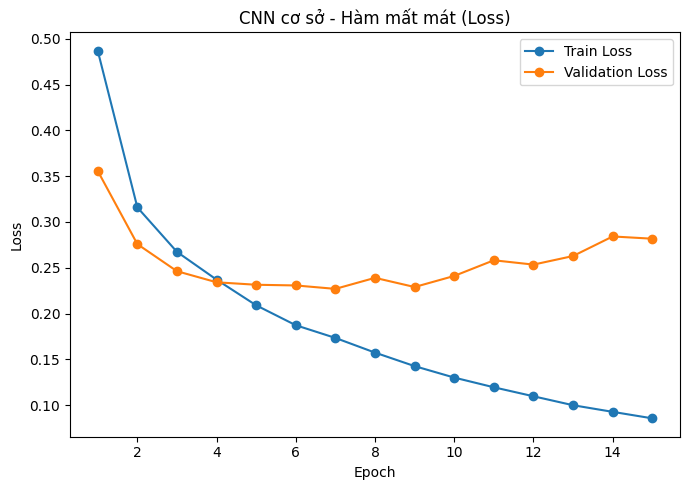

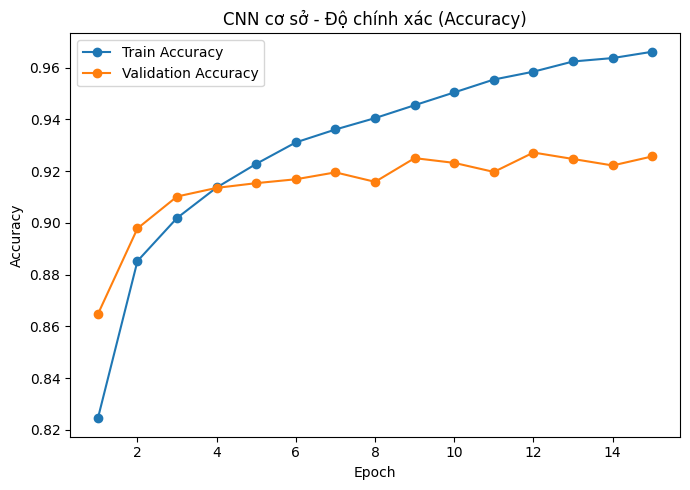

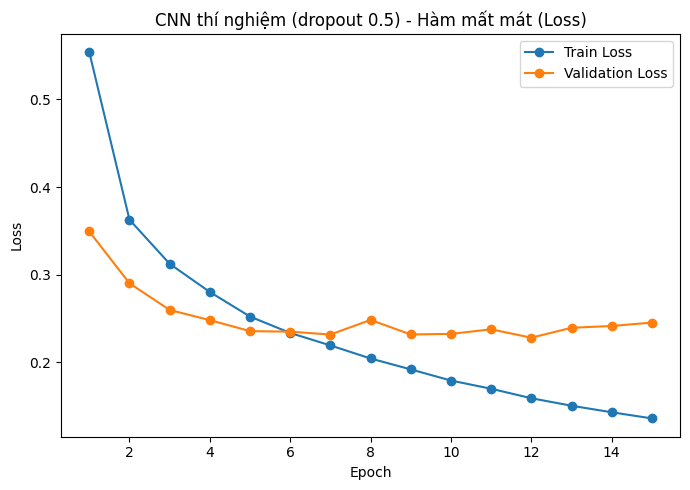

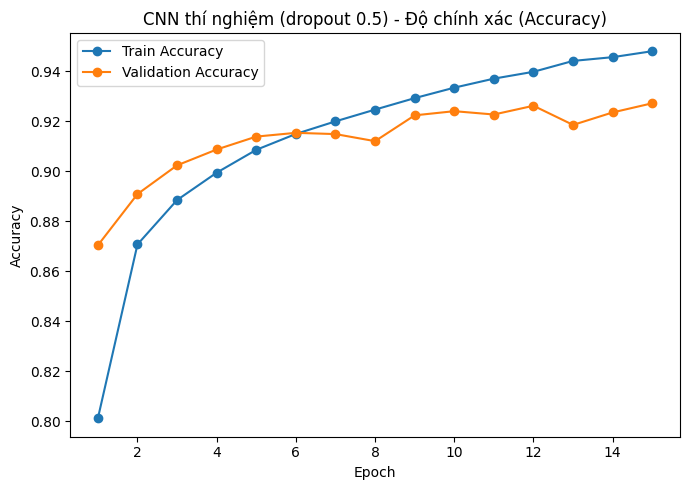

In [3]:
histories = {}
for label, run_dir in RUNS.items():
    history_df = pd.read_csv(run_dir / "metrics" / "history.csv")
    histories[label] = history_df

    fig = plot_loss_curve(history_df, title=f"{label} - Hàm mất mát (Loss)")
    fig.show()

    fig = plot_accuracy_curve(history_df, title=f"{label} - Độ chính xác (Accuracy)")
    fig.show()


## Epoch tốt nhất và kiểm tra overfitting

Với mỗi lần chạy: epoch tốt nhất (validation loss thấp nhất), và khoảng cách giữa
train accuracy và validation accuracy ở epoch cuối (một thước đo đơn giản, dễ giải thích
cho overfitting - khoảng cách càng tăng qua các epoch cho thấy mô hình đang "học thuộc"
dữ liệu huấn luyện).


In [4]:
rows = []
for label, history_df in histories.items():
    final_row = history_df.iloc[-1]
    best_epoch_row = history_df.loc[history_df["val_loss"].idxmin()]
    rows.append({
        "lan_chay": label,
        "epoch_tot_nhat": int(best_epoch_row["epoch"]),
        "val_loss_tot_nhat": best_epoch_row["val_loss"],
        "val_accuracy_tot_nhat": best_epoch_row["val_accuracy"],
        "train_accuracy_cuoi": final_row["train_accuracy"],
        "val_accuracy_cuoi": final_row["val_accuracy"],
        "khoang_cach_train_val_cuoi": final_row["train_accuracy"] - final_row["val_accuracy"],
    })

pd.DataFrame(rows)


,lan_chay,epoch_tot_nhat,val_loss_tot_nhat,val_accuracy_tot_nhat,train_accuracy_cuoi,val_accuracy_cuoi,khoang_cach_train_val_cuoi
0,MLP cơ sở,11,0.301826,0.890167,0.912778,0.890333,0.022444
1,CNN cơ sở,7,0.226952,0.919500,0.966130,0.925667,0.040463
2,CNN thí nghiệm (dropout 0.5),12,0.228184,0.926167,0.948000,0.927167,0.020833


## Nhận xét

- **MLP so với CNN:** CNN baseline đạt validation accuracy tốt nhất cao hơn rõ rệt so với
  MLP baseline (xem bảng tổng hợp ở trên), phù hợp với giả thuyết rằng việc khai thác cấu
  trúc không gian 2D thông qua convolution giúp ích cho dữ liệu ảnh.
- **CNN baseline so với CNN experiment (dropout 0.5):** train accuracy của CNN baseline
  tiếp tục tăng vượt xa epoch tốt nhất trong khi validation accuracy chững lại/giảm nhẹ -
  dấu hiệu của overfitting nhẹ. CNN experiment, với dropout cao hơn, cho thấy khoảng cách
  train/validation accuracy ở epoch cuối nhỏ hơn, ủng hộ giả thuyết rằng dropout mạnh hơn
  giúp giảm overfitting trên kiến trúc này.
- Dựa trên validation accuracy, `cnn/run_002` (CNN experiment) được chọn làm mô hình cuối
  cùng, và được đánh giá trên tập test chính thức trong `03_error_analysis.ipynb`.
